<a href="https://colab.research.google.com/github/RyanChang2004/GNN/blob/main/HGT_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install torch==2.8.0+cu128 torchvision --index-url https://download.pytorch.org/whl/cu128
!pip install torch_geometric==2.8.0 pyg-lib==0.6.0+pt28cu128 torch-scatter==2.1.2+pt28cu128 torch-sparse==0.6.18+pt28cu128 -f https://data.pyg.org/whl/torch-2.8.0+cu128.html

Looking in indexes: https://download.pytorch.org/whl/cu128
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu128.html


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import torch
from torch_geometric.data import HeteroData

# Load the heterodata object from the saved file
# WARNING: Setting weights_only=False can allow arbitrary code execution.
# Only do this if you trust the source of the 'heterodata.pt' file.
data = torch.load('/content/drive/MyDrive/GNN/heterodata.pt', weights_only=False)

# Display the loaded data (adjust based on the actual content of 'data')
print(data)

HeteroData(
  gene={ x=[871, 286] },
  (gene, coexpression, gene)={
    edge_index=[2, 51589],
    edge_attr=[51589, 4],
  },
  (gene, ppi, gene)={
    edge_index=[2, 81630],
    edge_attr=[81630, 4],
  }
)


In [6]:
import pandas as pd

df_l1000_y_source = pd.read_parquet('/content/drive/MyDrive/GNN/L1000_Hierarchical_Matrix.parquet')
df_x = pd.read_csv(
    '/content/drive/MyDrive/GNN/OSA_merged_tumor_gene_count_matrix.tsv',
    sep='\t', index_col='Gene ID'
)

# --- User can change this to select a different column for y values ---
Y_COLUMN_NAME = 'CPC003_HA1E_24H:BRD-A60414806-065-01-6:10' # Default to the first column
# You can view available columns by uncommenting the line below:
# print("Available columns in L1000_Hierarchical_Matrix:", df_l1000_y_source.columns.tolist())
# Example: Y_COLUMN_NAME = 'some_other_column_name'
# ----------------------------------------------------------------------

y_from_l1000_aligned = df_l1000_y_source[Y_COLUMN_NAME].reindex(df_x.index)

# Check for NaN values introduced by reindexing
# If NaNs are present, filter out these nodes instead of filling with 0.
if y_from_l1000_aligned.isnull().any():
    print("Warning: Some genes in your current node set (from df_x) do not have corresponding y values in L1000_Hierarchical_Matrix.parquet.")
    print("Instead of filling NaNs with 0, we will filter out these nodes from the dataset.")

    # Create a mask for rows with valid y values
    valid_y_mask = ~y_from_l1000_aligned.isnull()

    # Filter y_from_l1000_aligned to keep only valid values
    y_from_l1000_aligned = y_from_l1000_aligned[valid_y_mask]

    # Get the indices (Gene IDs) of nodes with valid y values
    valid_gene_ids = y_from_l1000_aligned.index

    # Filter df_x and x (feature tensor) to only include nodes with valid y values
    # Use 'global' keyword to ensure we modify the global variables defined earlier
    global df_x, x, node_set
    df_x = df_x.loc[valid_gene_ids]
    x = torch.tensor(df_x.values, dtype=torch.float) # Recreate x with filtered df_x
    node_set = set(df_x.index.astype(str)) # Update node_set

    print(f"Filtered out {valid_y_mask.sum().item()} nodes with NaN y values. Remaining nodes: {len(node_set)}")
else:
    print("No NaN values found in y_from_l1000_aligned. No nodes were filtered.")

# Convert the aligned y values to a PyTorch tensor
y_tensor = torch.tensor(y_from_l1000_aligned.values, dtype=torch.float).unsqueeze(1)

print(f"y values shape: {y_tensor.shape}")

Instead of filling NaNs with 0, we will filter out these nodes from the dataset.
Filtered out 871 nodes with NaN y values. Remaining nodes: 871
y values shape: torch.Size([871, 1])


<!--
### 0. 載入 `gene` 節點的特徵 `x`

根據您的指示，我們將從 `/content/drive/MyDrive/GNN/OSA_merged_tumor_gene_count_matrix.tsv` 載入基因計數矩陣作為 `gene` 節點的特徵 `x`。確保此數據的維度與異構圖中的基因節點匹配。
-->

### 1. 加入 `y` 並將其分類為三個部分

我們將從 `L1000_Hierarchical_Matrix.parquet` 載入基因對藥物的反應數據。這裡假設 `L1000_Hierarchical_Matrix.parquet` 的每一行對應一個基因，並且列是不同的藥物反應值。我們將計算每個基因的平均反應作為其連續 `y` 值，然後使用分位數將其分為三個類別。

In [7]:
import pandas as pd
import numpy as np
import torch

# Directly use the y_tensor prepared in the jVemGLuckSED cell
# y_tensor already contains aligned continuous y values, with NaN handled.
data['gene'].continuous_y = y_tensor # Store continuous y for regression target

# Convert y_tensor to a numpy array for classification using pandas/numpy
gene_y_values_np = y_tensor.squeeze().cpu().numpy()

continuous_y_for_plot = gene_y_values_np.copy() # For subsequent plotting

# Classify continuous y values into 3 parts
valid_y_values = gene_y_values_np

if len(valid_y_values) > 0:
    # --- Custom fixed interval boundaries ---
    # New intervals: (< -0.5), [-0.5, 0.5], (> 0.5)
    bin_edges = [
        -0.5,
        0.5
    ]

    # Use np.digitize to assign values to different bins
    # np.digitize behavior:
    # x < bin_edges[0]          -> 0
    # bin_edges[0] <= x < bin_edges[1] -> 1
    # x >= bin_edges[1]         -> 2
    # This matches the user's requirement (y < -0.5, -0.5 <= y <= 0.5, y > 0.5) mapped to 0, 1, 2.
    temp_y_categorical = np.digitize(valid_y_values, bin_edges, right=True)

    num_classes = 3 # Change to 3 classes
    print("y values have been classified into 3 intervals based on custom fixed numerical intervals.")

else:
    print("No valid y values available for classification. y for all genes will be set to 0, and there will be only one class.")
    temp_y_categorical = np.array([]) # Empty array, will be handled below
    num_classes = 1

# Convert classification result to PyTorch tensor and assign to data['gene'].y
# Since y_tensor has been filtered and aligned, temp_y_categorical can be used directly here
data['gene'].y = torch.tensor(temp_y_categorical, dtype=torch.long)
data.num_classes = num_classes # Store the number of classes in the data object for later use

print(f"y values for 'gene' nodes have been added and classified. Number of classes created: {data.num_classes}")
print("Partial y values for 'gene' nodes: ", data['gene'].y[:10])
print(data)

y values have been classified into 3 intervals based on custom fixed numerical intervals.
y values for 'gene' nodes have been added and classified. Number of classes created: 3
Partial y values for 'gene' nodes:  tensor([0, 0, 0, 0, 0, 1, 2, 2, 0, 1])
HeteroData(
  num_classes=3,
  gene={
    x=[871, 286],
    continuous_y=[871, 1],
    y=[871],
  },
  (gene, coexpression, gene)={
    edge_index=[2, 51589],
    edge_attr=[51589, 4],
  },
  (gene, ppi, gene)={
    edge_index=[2, 81630],
    edge_attr=[81630, 4],
  }
)


### 2. 建立 DataLoader 並處理驗證集

我們將為 `gene` 節點創建訓練、驗證和測試掩碼。您提到「取特定的五種藥物做 validation」，這表示您的驗證集應包含與這五種特定藥物相關的基因。目前由於缺乏如何識別這些基因的具體信息，我們將首先演示一個隨機分割。在實際應用中，您需要將以下隨機分割邏輯替換為基於特定藥物的基因選擇邏輯。

此外，對於單個大型異構圖，`DataLoader` 通常不是用來對圖本身進行批處理，而是用於對節點或子圖進行採樣（例如使用 `NeighborLoader`）。這裡，我們將圖包裝在一個列表中以符合 `DataLoader` 的輸入格式，這在單圖節點分類任務中通常只作為一個大小為 1 的批次處理。

In [8]:
!pip show torch-sparse

Name: torch_sparse
Version: 0.6.18+pt28cu128
Summary: PyTorch Extension Library of Optimized Autograd Sparse Matrix Operations
Home-page: https://github.com/rusty1s/pytorch_sparse
Author: Matthias Fey
Author-email: matthias.fey@tu-dortmund.de
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: scipy
Required-by: 


In [9]:
from sklearn.model_selection import StratifiedShuffleSplit
import torch
from torch_geometric.loader import HGTLoader
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 定義訓練和驗證的比例
train_ratio = 0.8
val_ratio = 0.2

num_nodes = data['gene'].num_nodes

# 過濾掉 y 值為 -1 (未分配/NaN) 的節點，這些節點不參與訓練和驗證
valid_node_indices = torch.where(data['gene'].y != -1)[0]
valid_num_nodes = len(valid_node_indices)

# 獲取有效的 y 值作為分層抽樣的依據
valid_y = data['gene'].y[valid_node_indices].cpu().numpy()

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)

if valid_num_nodes == 0:
    print("沒有有效的基因節點帶有 y 值，無法進行數據分割。")
elif data.num_classes == 1 or len(np.unique(valid_y)) == 1: # 如果只有一個類別，分層抽樣會出錯，退回隨機抽樣
    print("警告: 只有一個 Y 類別，將進行隨機數據分割而非分層抽樣。")
    indices = torch.randperm(valid_num_nodes)
    num_train_valid = int(valid_num_nodes * train_ratio)
    train_mask[valid_node_indices[indices[:num_train_valid]]] = True
    val_mask[valid_node_indices[indices[num_train_valid:]]] = True
else:
    # 使用 StratifiedShuffleSplit 進行分層抽樣
    # n_splits=1, test_size=val_ratio 意味著 validation set 會是 val_ratio 的比例
    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=42)

    # sss.split 需要 (X, y)，其中 X 可以是任何可迭代的，但其長度必須與 y 相同
    # 我們只關心索引，所以 X 可以是 dummy array
    for train_idx_valid, val_idx_valid in sss.split(np.zeros(valid_num_nodes), valid_y):
        # 將索引映射回原始的基因節點索引
        train_mask[valid_node_indices[train_idx_valid]] = True
        val_mask[valid_node_indices[val_idx_valid]] = True

data['gene'].train_mask = train_mask
data['gene'].val_mask = val_mask

print(f"為 'gene' 節點創建了訓練/驗證掩碼:")
print(f"總有效節點數: {valid_num_nodes}, 訓練集: {train_mask.sum()}, 驗證集: {val_mask.sum()}")

# 打印訓練集和驗證集的 y 分佈，以確認分層抽樣效果
if valid_num_nodes > 0 and data.num_classes > 1:
    print("訓練集 y 分佈:", torch.bincount(data['gene'].y[train_mask]))
    print("驗證集 y 分佈:", torch.bincount(data['gene'].y[val_mask]))

# --- 移除類別權重 (所有類別權重均設置為 1.0) ----
# 創建一個所有權重都為 1.0 的 numpy 陣列
class_weights_np = np.ones(data.num_classes, dtype=np.float32)
print("已移除所有類別加權，所有類別的權重均設置為 1.0。")
# ----------------------------------------

# 將 numpy 陣列轉換為 PyTorch tensor，並移動到設備上 (稍後會在模型訓練時移動到 GPU)
class_weights = torch.tensor(class_weights_np, dtype=torch.float)

# 創建一個 tensor，其中包含每個基因節點對應的類別權重
# 這樣在計算損失時，我們可以根據每個樣本的真實類別來應用權重
node_class_weights = torch.zeros(num_nodes, dtype=torch.float)
for i in range(data.num_classes):
    class_i_mask = (data['gene'].y == i)
    node_class_weights[class_i_mask] = class_weights[i]

data.node_class_weights = node_class_weights # 將權重儲存在 data 物件中

print(f"\n計算出的類別權重: {class_weights}")
print(f"已為每個基因節點創建了對應的類別權重 tensor (前10個): {data.node_class_weights[:10]}")

# 創建 HGTLoader
# dataset = [data] # Removed this line as it was causing the error
train_loader = HGTLoader(data, batch_size=64, input_nodes=('gene', data['gene'].train_mask), num_samples=[40, 20], shuffle=True) # 增加 num_samples
val_loader = HGTLoader(data, batch_size=64, input_nodes=('gene', data['gene'].val_mask), num_samples=[40, 20]) # 增加 num_samples

print("\n已創建 HGTLoaders。")
print(f"訓練集 HGTLoaders 中的第一批數據: {next(iter(train_loader))}")

為 'gene' 節點創建了訓練/驗證掩碼:
總有效節點數: 871, 訓練集: 696, 驗證集: 175
訓練集 y 分佈: tensor([268, 126, 302])
驗證集 y 分佈: tensor([67, 32, 76])
已移除所有類別加權，所有類別的權重均設置為 1.0。

計算出的類別權重: tensor([1., 1., 1.])
已為每個基因節點創建了對應的類別權重 tensor (前10個): tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

已創建 HGTLoaders。
訓練集 HGTLoaders 中的第一批數據: HeteroData(
  num_classes=3,
  node_class_weights=[871],
  gene={
    x=[124, 286],
    continuous_y=[124, 1],
    y=[124],
    train_mask=[124],
    val_mask=[124],
    n_id=[124],
    input_id=[64],
    batch_size=64,
  },
  (gene, coexpression, gene)={
    edge_index=[2, 1019],
    edge_attr=[1019, 4],
    e_id=[1019],
  },
  (gene, ppi, gene)={
    edge_index=[2, 950],
    edge_attr=[950, 4],
    e_id=[950],
  }
)


### 3.2. Regression then Classification Approach

Instead of direct classification, we will now implement a two-step process: first, a regression model will predict continuous `y` values, and then these continuous predictions will be classified into three categories. This approach might capture more nuanced relationships before discretization.

We will define a separate HGT model for regression and adapt the training and evaluation procedures accordingly.

In [10]:
from typing import Tuple
import torch
import torch.nn.functional as F
from torch_geometric.nn import HGTConv, Linear
import torch.nn as nn

class HGTRegression(torch.nn.Module):
    def __init__(self, hidden_channels, num_heads, num_layers, node_types, edge_types, node_features_dict):
        super().__init__()

        self.hidden_channels = hidden_channels
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.encoder = torch.nn.ModuleDict()
        self.encoder['gene'] = Linear(-1, hidden_channels)
        self.activation = nn.ReLU()

        # 明確定義 'gene' 節點的特徵編碼器。
        # 它將原始特徵維度 (根據目前 `data['gene'].x` 為 222 維) 投影到 `hidden_channels`。
        # 這層作為初始特徵轉換/編碼器，與 GNN 一同訓練。
        # self.encoder = Linear() self.activation = ReLU() self.activation(self.encoder(x_dict['gene']))

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(HGTConv(hidden_channels, hidden_channels, data.metadata(), num_heads))

        # 輸出層用於回歸：單個連續值
        self.regression_head = Linear(hidden_channels, 1)

    def forward(self, x_dict, edge_index_dict):
        # 將顯式 gene 編碼器應用於 'gene' 節點特徵
        x_dict_out = {
            'gene': self.activation(self.encoder['gene'](x))
            for x in x_dict.values()
        }
        # 移除 x_dict_out['gene'] = self.dropout(x_dict_out['gene']) # 移除 encoder 後的 dropout

        for conv in self.convs:
            x_dict_out = conv(x_dict_out, edge_index_dict)

        # 返回 'gene' 節點的原始連續預測
        # 重新加入 regression_head 以將 hidden_channels 輸出轉換為單一回歸值
        return 8 * torch.tanh(self.regression_head(x_dict_out['gene']))

print("HGT Regression 模型定義完成，並在每個 HGTConv 層後新增 ReLU 激活。")
print(data.metadata())
print(data.node_types)
print(data.edge_types)

HGT Regression 模型定義完成，並在每個 HGTConv 層後新增 ReLU 激活。
(['gene'], [('gene', 'coexpression', 'gene'), ('gene', 'ppi', 'gene')])
['gene']
[('gene', 'coexpression', 'gene'), ('gene', 'ppi', 'gene')]


In [11]:
import torch.nn as nn
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
import numpy as np
import torch.nn.functional as F
import torch.optim as optim

def train_regression(model, optimizer, data, train_mask, target_y_continuous, node_class_weights):
    model.train()
    optimizer.zero_grad()

    out = model(data.x_dict, data.edge_index_dict)
    target_y = target_y_continuous[train_mask].float().flatten()

    # Get global node IDs for the current batch
    global_node_ids_in_batch = data['gene'].n_id
    # Use these global IDs to retrieve the corresponding global weights
    # The node_class_weights tensor is global (871 elements), so we index it with global IDs from the batch.
    node_class_weights_for_batch = node_class_weights[global_node_ids_in_batch]
    # Apply the batch's train_mask to get weights for the training samples within this batch
    current_sample_weights = node_class_weights_for_batch[train_mask].to(data.x_dict['gene'].device)

    # 使用 MSE 誤差 (Mean Squared Error) 進行回歸
    # Calculate element-wise squared error
    element_wise_squared_error = torch.square(out[train_mask].flatten() - target_y)
    # Apply weights and then take the mean
    loss = (element_wise_squared_error * current_sample_weights).mean()

    loss.backward()

    # --- 用於印出梯度的示範 ---
    # 您可以選擇任何模型的參數來檢查其梯度
    # 例如，檢查回歸頭的權重 (regression_head.weight) 的梯度
    if model.regression_head.weight.grad is not None:
        # 為了避免輸出過多，我們只印出梯度的統計信息，而不是整個張量
        # 例如，印出梯度的平均值和最大絕對值
        grad_mean = model.regression_head.weight.grad.mean().item()
        grad_max_abs = model.regression_head.weight.grad.abs().max().item()
        # print(f"  [Grad Check] regression_head.weight grad mean: {grad_mean:.6f}, max abs: {grad_max_abs:.6f}")
        # 如果您想看到完整的梯度張量 (不建議在每次迭代都印出):
        # print(f"  [Grad Check] regression_head.weight grad: {model.regression_head.weight.grad}")
    # -----------------------------

    optimizer.step()
    return loss.item()

def evaluate_regression(model, data, mask, target_y_continuous, node_class_weights):
    model.eval()
    with torch.no_grad():
        # Check if the mask is empty (no samples in this batch for the given mask)
        # This is a preliminary check before actual data extraction
        if mask.sum() == 0:
            # Return inf for RMSE and loss, 0.0 for accuracy to prevent errors and handle early stopping correctly
            return float('inf'), float('inf'), 0.0

        out = model(data.x_dict, data.edge_index_dict)

        target_y_continuous_masked = target_y_continuous[mask].float().flatten()

        # Get global node IDs for the current batch
        global_node_ids_in_batch = data['gene'].n_id
        # Use these global IDs to retrieve the corresponding global weights
        node_class_weights_for_batch = node_class_weights[global_node_ids_in_batch]
        # Apply the batch's mask to get weights for the samples within this batch
        current_sample_weights = node_class_weights_for_batch[mask].to(data.x_dict['gene'].device)

        # 使用 MSE 誤差 (用於評估時的 loss)
        element_wise_squared_error = torch.square(out[mask].flatten() - target_y_continuous_masked)
        loss = (element_wise_squared_error * current_sample_weights).mean().item()

        # Calculate RMSE
        pred_continuous = out[mask].flatten().cpu().numpy()
        true_continuous = target_y_continuous_masked.cpu().numpy()

        # --- Additional check to handle cases where arrays might still be empty ---
        if true_continuous.size == 0 or pred_continuous.size == 0:
            # This catches scenarios where mask.sum() > 0 but the resulting numpy arrays are empty
            return float('inf'), float('inf'), 0.0
        # ----------------------------------------------------------------------

        rmse = np.sqrt(mean_squared_error(true_continuous, pred_continuous))

        # Calculate Classification Accuracy
        true_categorical_labels = data['gene'].y[mask].cpu().numpy()
        bin_edges = [-0.5, 0.5]
        predicted_categorical_labels = np.digitize(pred_continuous, bin_edges, right=True)
        accuracy = accuracy_score(true_categorical_labels, predicted_categorical_labels)

    return rmse, loss, accuracy

In [12]:
# 獲取異構圖的元數據 (節點類型和邊類型)
metadata = (data.node_types, data.edge_types)

# HGT Regression 模型參數
hidden_channels = 128  # 隱藏層維度
num_heads = 4        # 注意力頭數
num_layers = 2       # HGT 層數

# 初始化 HGT Regression 模型
regression_model = HGTRegression(
    hidden_channels=hidden_channels,
    num_heads=num_heads,
    num_layers=num_layers,
    node_types=data.node_types,
    edge_types=data.edge_types,
    node_features_dict=data.x_dict,
)

regression_optimizer = optim.Adam(regression_model.parameters(), lr=0.0005, weight_decay=5e-4)

# 將模型和類別權重移動到 GPU (如果可用)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
regression_model.to(device)
node_class_weights = data.node_class_weights.to(device) # 將權重 tensor 移動到設備上
print(f"回歸模型和類別權重已移動到: {device}")

回歸模型和類別權重已移動到: cuda


In [13]:
# --- 回歸訓練循環 ---
epochs_regression = 150 # 設置回歸訓練輪數

# Early Stopping 參數
patience = 40 # 在多少個 epoch 內驗證集 RMSE 沒有改善就停止
min_delta = 0.0001 # 認為 RMSE 有改善的最小變化量
counter = 0 # 計數器，記錄沒有改善的 epoch 數量
best_val_rmse = float('inf')
best_regression_model_state = None
early_stop_triggered = False

print(f"\n開始訓練 HGT 回歸模型，總共 {epochs_regression} 輪 (已啟用類別權重，並開啟 Early Stopping)... ")

for epoch in range(1, epochs_regression + 1):
    for batch_data in train_loader: # train_loader 只包含一個圖
        batch_data = batch_data.to(device)
        loss = train_regression(regression_model, regression_optimizer, batch_data,
                                batch_data['gene'].train_mask, batch_data['gene'].continuous_y,
                                node_class_weights) # 傳遞類別權重

    train_rmse, train_loss, train_acc = evaluate_regression(regression_model, batch_data,
                                                 batch_data['gene'].train_mask, batch_data['gene'].continuous_y,
                                                 node_class_weights) # 傳遞類別權重
    val_rmse, val_loss, val_acc = evaluate_regression(regression_model, batch_data,
                                             batch_data['gene'].val_mask, batch_data['gene'].continuous_y,
                                             node_class_weights) # 傳遞類別權重

    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train RMSE: {train_rmse:.4f}, Val RMSE: {val_rmse:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

    # Early Stopping 邏輯
    if val_rmse < best_val_rmse - min_delta:
        best_val_rmse = val_rmse
        best_regression_model_state = regression_model.state_dict() # 保存最佳模型狀態
        counter = 0 # 重置計數器
        print(f"  --> New best validation RMSE: {best_val_rmse:.4f}, saving model state.")
    else:
        counter += 1
        print(f"  --> Validation RMSE did not improve. Counter: {counter}/{patience}")
        if counter >= patience:
            print(f"  --> Early stopping triggered after {patience} epochs without improvement.")
            early_stop_triggered = True
            break

if early_stop_triggered:
    print("HGT 回歸模型訓練因 Early Stopping 而提前結束。")
else:
    print("HGT 回歸模型訓練完成。")


開始訓練 HGT 回歸模型，總共 150 輪 (已啟用類別權重，並開啟 Early Stopping)... 
Epoch: 001, Loss: 7.7477, Train RMSE: 2.7289, Val RMSE: 1.7916, Train Acc: 0.3364, Val Acc: 0.4444
  --> New best validation RMSE: 1.7916, saving model state.
Epoch: 002, Loss: 6.1199, Train RMSE: 2.4782, Val RMSE: 2.0887, Train Acc: 0.2212, Val Acc: 0.1667
  --> Validation RMSE did not improve. Counter: 1/40
Epoch: 003, Loss: 5.3882, Train RMSE: 2.3009, Val RMSE: 2.8069, Train Acc: 0.2449, Val Acc: 0.2222
  --> Validation RMSE did not improve. Counter: 2/40
Epoch: 004, Loss: 4.9579, Train RMSE: 2.2136, Val RMSE: 2.4257, Train Acc: 0.3333, Val Acc: 0.4545
  --> Validation RMSE did not improve. Counter: 3/40
Epoch: 005, Loss: 4.4384, Train RMSE: 2.1065, Val RMSE: 2.4749, Train Acc: 0.2941, Val Acc: 0.3571
  --> Validation RMSE did not improve. Counter: 4/40
Epoch: 006, Loss: 5.7360, Train RMSE: 2.3740, Val RMSE: 2.5218, Train Acc: 0.2255, Val Acc: 0.0000
  --> Validation RMSE did not improve. Counter: 5/40
Epoch: 007, Loss: 5.5611

In [14]:
# --- 使用最佳回歸模型進行預測並分類 ---
if best_regression_model_state:
    regression_model.load_state_dict(best_regression_model_state)
    print("已載入最佳回歸模型狀態進行最終預測和分類。")
else:
    print("未找到最佳回歸模型狀態，將使用最後一個 epoch 的模型。")

regression_model.eval()
with torch.no_grad():
    data = data.to(device) # Ensure data is on the correct device
    all_gene_continuous_predictions = regression_model(data.x_dict, data.edge_index_dict).squeeze()

# 將連續預測值分類為 3 個部分
bin_edges = [-0.5, 0.5]
classified_predictions_np = np.digitize(all_gene_continuous_predictions.cpu().numpy(), bin_edges, right=True)
classified_predictions_tensor = torch.tensor(classified_predictions_np, dtype=torch.long).to(device)

# 評估回歸後分類的性能
true_labels_train = data['gene'].y[data['gene'].train_mask]
predicted_labels_train = classified_predictions_tensor[data['gene'].train_mask]
train_acc_classified = accuracy_score(true_labels_train.cpu().numpy(), predicted_labels_train.cpu().numpy())

true_labels_val = data['gene'].y[data['gene'].val_mask]
predicted_labels_val = classified_predictions_tensor[data['gene'].val_mask]
val_acc_classified = accuracy_score(true_labels_val.cpu().numpy(), predicted_labels_val.cpu().numpy())

print(f"\n--- 回歸後分類結果 (啟用類別權重) ---")
print(f"訓練集分類準確度: {train_acc_classified:.4f}")
print(f"驗證集分類準確度: {val_acc_classified:.4f}")

# Store the classified predictions for later confusion matrix display
regression_then_classified_predictions = classified_predictions_tensor

已載入最佳回歸模型狀態進行最終預測和分類。

--- 回歸後分類結果 (啟用類別權重) ---
訓練集分類準確度: 0.4655
驗證集分類準確度: 0.3543


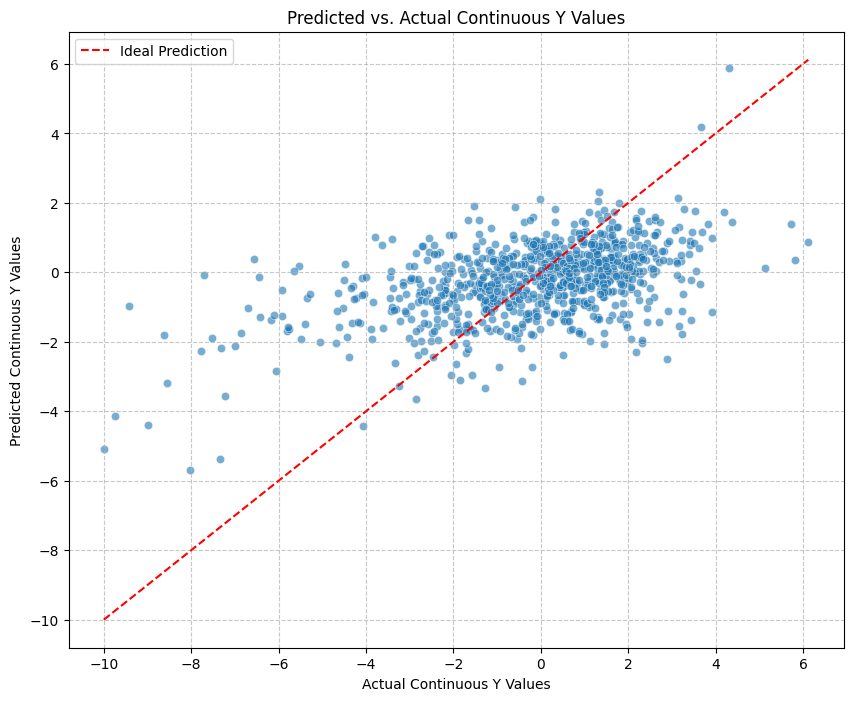

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 將數據從 tensor 轉換為 numpy，以便繪圖
true_continuous_y = data['gene'].continuous_y.cpu().numpy().flatten()
predicted_continuous_y = all_gene_continuous_predictions.cpu().numpy().flatten()

# 創建散點圖
plt.figure(figsize=(10, 8))
sns.scatterplot(x=true_continuous_y, y=predicted_continuous_y, alpha=0.6)

# 添加對角線 (理想預測線)
min_val = min(true_continuous_y.min(), predicted_continuous_y.min())
max_val = max(true_continuous_y.max(), predicted_continuous_y.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Prediction')

plt.title('Predicted vs. Actual Continuous Y Values')
plt.xlabel('Actual Continuous Y Values')
plt.ylabel('Predicted Continuous Y Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()



--- Training Set Confusion Matrix (Regression then Classification) ---


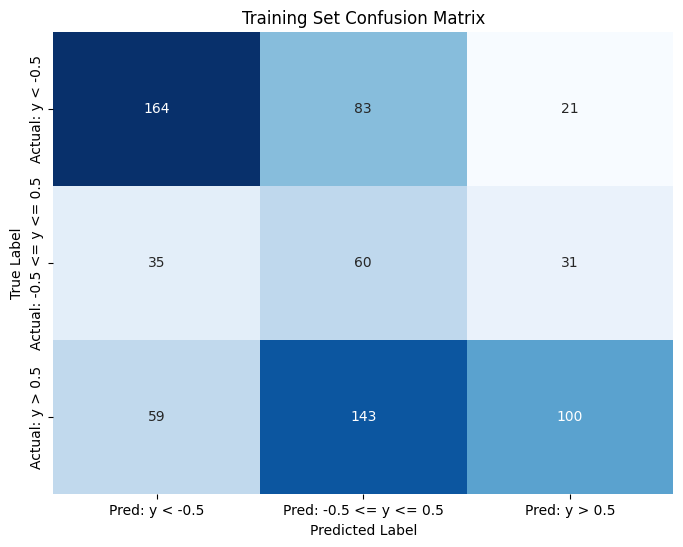

Overall Accuracy: 0.4655
Sensitivity (y < -0.5): 0.6119
Sensitivity (-0.5 <= y <= 0.5): 0.4762
Sensitivity (y > 0.5): 0.3311

--- Validation Set Confusion Matrix (Regression then Classification) ---


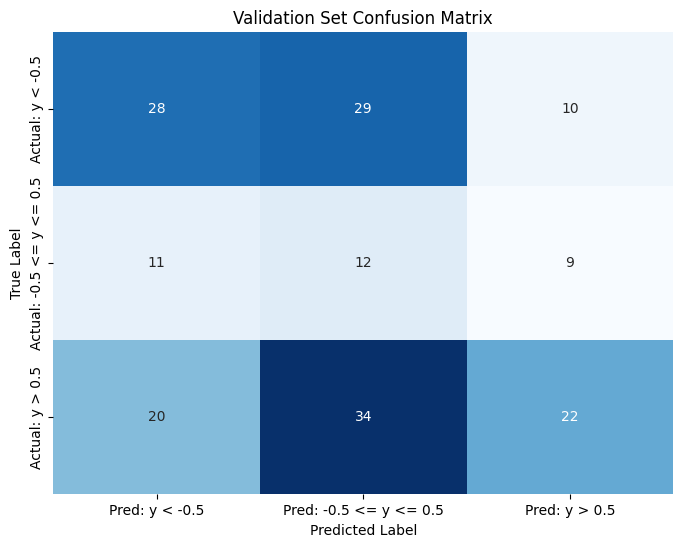

Overall Accuracy: 0.3543
Sensitivity (y < -0.5): 0.4179
Sensitivity (-0.5 <= y <= 0.5): 0.3750
Sensitivity (y > 0.5): 0.2895
Regression-then-Classification confusion matrices generated with heatmaps, sensitivity, and accuracy.


In [16]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming 'regression_then_classified_predictions' is available from the previous step

# Define class labels based on the bin_edges used for classification
class_labels = [
    'y < -0.5',
    '-0.5 <= y <= 0.5',
    'y > 0.5'
]

# Helper function to calculate sensitivity and accuracy from confusion matrix
def calculate_metrics(cm, class_labels):
    metrics = {}
    num_classes = cm.shape[0]
    overall_accuracy = np.trace(cm) / np.sum(cm)
    metrics['Overall Accuracy'] = overall_accuracy

    sensitivities = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        sensitivities.append(sensitivity)
        metrics[f'Sensitivity ({class_labels[i]})'] = sensitivity
    return metrics

# --- Training Set Confusion Matrix (Regression then Classification) ---
train_mask = data['gene'].train_mask
train_pred_reg_cls = regression_then_classified_predictions[train_mask]
train_true_reg_cls = data['gene'].y[train_mask]

cm_train_reg_cls = confusion_matrix(train_true_reg_cls.cpu().numpy(), train_pred_reg_cls.cpu().numpy(), labels=range(data.num_classes))
df_cm_train_reg_cls = pd.DataFrame(cm_train_reg_cls, index=class_labels, columns=class_labels)

print("\n--- Training Set Confusion Matrix (Regression then Classification) ---")
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm_train_reg_cls, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Pred: {l}' for l in class_labels], yticklabels=[f'Actual: {l}' for l in class_labels])
plt.title('Training Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

train_metrics = calculate_metrics(cm_train_reg_cls, class_labels)
for key, value in train_metrics.items():
    print(f"{key}: {value:.4f}")

# --- Validation Set Confusion Matrix (Regression then Classification) ---
val_mask = data['gene'].val_mask
val_pred_reg_cls = regression_then_classified_predictions[val_mask]
val_true_reg_cls = data['gene'].y[val_mask]

cm_val_reg_cls = confusion_matrix(val_true_reg_cls.cpu().numpy(), val_pred_reg_cls.cpu().numpy(), labels=range(data.num_classes))
df_cm_val_reg_cls = pd.DataFrame(cm_val_reg_cls, index=class_labels, columns=class_labels)

print("\n--- Validation Set Confusion Matrix (Regression then Classification) ---")
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm_val_reg_cls, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Pred: {l}' for l in class_labels], yticklabels=[f'Actual: {l}' for l in class_labels])
plt.title('Validation Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

val_metrics = calculate_metrics(cm_val_reg_cls, class_labels)
for key, value in val_metrics.items():
    print(f"{key}: {value:.4f}")

print("Regression-then-Classification confusion matrices generated with heatmaps, sensitivity, and accuracy.")

### 檢查 Dataloader 內容

In [ ]:
print("開始檢查 train_loader 中的數據批次...")

# 取一個批次進行檢查
for i, batch_data in enumerate(train_loader):
    # 將數據移動到正確的設備上
    batch_data = batch_data.to(device)

    # 獲取 'gene' 節點的全局 ID
    gene_global_ids = batch_data['gene'].n_id.cpu().numpy()

    # 從原始 df_x 的索引中獲取對應的基因名稱
    # df_x 的索引已經是過濾後的基因 ID
    # 注意：這裡假設 df_x 在當前環境中是可用的，並且其索引包含了所有基因名稱
    gene_names_in_batch = df_x.index[gene_global_ids].tolist()

    print(f"\n批次 {i+1}: 基因節點名稱 (前 5 個):\n", gene_names_in_batch[:5])

    # 顯示 'gene' 節點的特徵 (x)
    print(f"批次 {i+1}: 基因節點特徵 (x_dict['gene']) 的形狀: {batch_data.x_dict['gene'].shape}")
    print("前 5 個基因節點的特徵值 (x_dict['gene'][:5]):\n", batch_data.x_dict['gene'][:5])

    # 顯示 'gene' 節點的連續 y 值 (continuous_y)
    print(f"批次 {i+1}: 基因節點連續 y 值 (continuous_y) 的形狀: {batch_data['gene'].continuous_y.shape}")
    print("前 5 個基因節點的連續 y 值 (continuous_y[:5]):\n", batch_data['gene'].continuous_y[:5])

    # 顯示 'gene' 節點的分類 y 值 (y)
    print(f"批次 {i+1}: 基因節點分類 y 值 (y) 的形狀: {batch_data['gene'].y.shape}")
    print("前 5 個基因節點的分類 y 值 (y[:5]):\n", batch_data['gene'].y[:5])

    # --- 新增：驗證基因名稱與連續 y 值對應關係 ---
    sample_count = min(5, len(gene_names_in_batch))
    print("\n--- 驗證基因名稱與 y 值對應關係 (取前 {} 個基因) ---".format(sample_count))
    for k in range(sample_count):
        gene_name = gene_names_in_batch[k]

        # 從當前批次的 batch_data['gene'].continuous_y 中獲取對應的 y 值
        # 這裡 k 是批次內的索引
        y_from_batch_data = batch_data['gene'].continuous_y[k].item()

        # 從原始的 y_from_l1000_aligned 中獲取對應的 y 值
        y_from_aligned_df = y_from_l1000_aligned.loc[gene_name]

        print(f"基因 '{gene_name}':")
        print(f"  來自 batch_data['gene'].continuous_y (批次內): {y_from_batch_data:.4f}")
        print(f"  來自 y_from_l1000_aligned (全局): {y_from_aligned_df:.4f}")
        if abs(y_from_batch_data - y_from_aligned_df) < 1e-6:
            print("  --> 值匹配")
        else:
            print("  --> 值不匹配！")
    # --- 驗證結束 ---

    # 我們只檢查一個批次就足夠了，以免輸出過多
    if i == 0:
        break

print("數據加載器檢查完成。")

開始檢查 train_loader 中的數據批次...

批次 1: 基因節點名稱 (前 5 個):
 ['ENSCAFG00845028314', 'ENSCAFG00845029792', 'ENSCAFG00845012026', 'ENSCAFG00845012103', 'ENSCAFG00845004060']
批次 1: 基因節點特徵 (x_dict['gene']) 的形狀: torch.Size([124, 286])
前 5 個基因節點的特徵值 (x_dict['gene'][:5]):
 tensor([[6.8167, 6.5410, 6.8565,  ..., 1.5345, 1.0584, 1.0259],
        [6.5058, 6.0426, 5.9375,  ..., 1.5345, 1.0584, 1.0259],
        [4.7875, 5.6768, 5.2883,  ..., 7.4571, 4.8959, 5.1047],
        [4.2485, 5.1120, 5.1533,  ..., 1.5345, 1.0584, 1.0259],
        [6.3226, 6.0379, 5.9322,  ..., 1.5345, 1.0584, 1.0259]],
       device='cuda:0')
批次 1: 基因節點連續 y 值 (continuous_y) 的形狀: torch.Size([124, 1])
前 5 個基因節點的連續 y 值 (continuous_y[:5]):
 tensor([[-0.8912],
        [-0.1800],
        [ 2.2622],
        [ 2.1040],
        [-2.7546]], device='cuda:0')
批次 1: 基因節點分類 y 值 (y) 的形狀: torch.Size([124])
前 5 個基因節點的分類 y 值 (y[:5]):
 tensor([0, 1, 2, 2, 0], device='cuda:0')

--- 驗證基因名稱與 y 值對應關係 (取前 5 個基因) ---
基因 'ENSCAFG00845028314':
  來自 batch_data

## 僅使用 'coexpression' 邊訓練模型

這個部分將演示如何僅使用 'coexpression' 邊來訓練 HGT 模型。我們將會複製原始的 `data` 物件，然後從中移除 'ppi' 邊，並重新初始化 HGT 模型和 `HGTLoader`。這有助於評估 'coexpression' 邊單獨對預測任務的貢獻。


In [ ]:
import copy

# 複製原始數據，避免修改
data_coexpression_only = copy.deepcopy(data)

# 移除 'ppi' 邊
if ('gene', 'ppi', 'gene') in data_coexpression_only.edge_types:
    del data_coexpression_only[('gene', 'ppi', 'gene')]
    print("已從複製的數據中移除 'ppi' 邊。")

# 更新 metadata 以反映新的邊類型
metadata_coexpression_only = (data_coexpression_only.node_types, data_coexpression_only.edge_types)
print(f"更新後的 metadata (僅 coexpression): {metadata_coexpression_only}")

# 重新創建 HGTLoader for coexpression only
train_loader_coexpression = HGTLoader(data_coexpression_only, batch_size=64, input_nodes=('gene', data_coexpression_only['gene'].train_mask), num_samples=[40, 20], shuffle=True)
val_loader_coexpression = HGTLoader(data_coexpression_only, batch_size=64, input_nodes=('gene', data_coexpression_only['gene'].val_mask), num_samples=[40, 20])

print("已為僅 coexpression 邊重新創建 HGTLoaders。")

# 重新初始化 HGT Regression 模型 (僅使用 coexpression 邊的 metadata)
regression_model_coexpression = HGTRegression(
    hidden_channels=hidden_channels,
    num_heads=num_heads,
    num_layers=num_layers,
    node_types=data_coexpression_only.node_types,
    node_features_dict=data_coexpression_only.x_dict,
    metadata=metadata_coexpression_only
)

regression_optimizer_coexpression = optim.Adam(regression_model_coexpression.parameters(), lr=0.0005, weight_decay=5e-4)

# 將模型移動到 GPU
regression_model_coexpression.to(device)

print("已為僅 coexpression 邊重新初始化 HGT Regression 模型。")

# --- 回歸訓練循環 (僅 coexpression 邊) ---
epochs_regression_coexpression = 150

# Early Stopping 參數
patience_coexpression = 20
min_delta_coexpression = 0.0001
counter_coexpression = 0
best_val_rmse_coexpression = float('inf')
best_regression_model_state_coexpression = None
early_stop_triggered_coexpression = False

print(f"\n開始訓練 HGT 回歸模型 (僅 coexpression 邊)，總共 {epochs_regression_coexpression} 輪 (已啟用類別權重，並開啟 Early Stopping)... ")

for epoch in range(1, epochs_regression_coexpression + 1):
    for batch_data in train_loader_coexpression:
        batch_data = batch_data.to(device)
        loss_coexpression = train_regression(regression_model_coexpression, regression_optimizer_coexpression, batch_data,
                                         batch_data['gene'].train_mask, batch_data['gene'].continuous_y,
                                         node_class_weights)

    train_rmse_coexpression, train_loss_coexpression, train_acc_coexpression = evaluate_regression(regression_model_coexpression, batch_data,
                                                                                         batch_data['gene'].train_mask, batch_data['gene'].continuous_y,
                                                                                         node_class_weights)
    val_rmse_coexpression, val_loss_coexpression, val_acc_coexpression = evaluate_regression(regression_model_coexpression, batch_data,
                                                                                     batch_data['gene'].val_mask, batch_data['gene'].continuous_y,
                                                                                     node_class_weights)

    print(f'Epoch: {epoch:03d}, Loss: {loss_coexpression:.4f}, Train RMSE: {train_rmse_coexpression:.4f}, Val RMSE: {val_rmse_coexpression:.4f}, Train Acc: {train_acc_coexpression:.4f}, Val Acc: {val_acc_coexpression:.4f}')

    # Early Stopping 邏輯
    if val_rmse_coexpression < best_val_rmse_coexpression - min_delta_coexpression:
        best_val_rmse_coexpression = val_rmse_coexpression
        best_regression_model_state_coexpression = regression_model_coexpression.state_dict()
        counter_coexpression = 0
        print(f"  --> New best validation RMSE: {best_val_rmse_coexpression:.4f}, saving model state.")
    else:
        counter_coexpression += 1
        print(f"  --> Validation RMSE did not improve. Counter: {counter_coexpression}/{patience_coexpression}")
        if counter_coexpression >= patience_coexpression:
            print(f"  --> Early stopping triggered after {patience_coexpression} epochs without improvement.")
            early_stop_triggered_coexpression = True
            break

if early_stop_triggered_coexpression:
    print("HGT 回歸模型訓練 (僅 coexpression 邊) 因 Early Stopping 而提前結束。")
else:
    print("HGT 回歸模型訓練 (僅 coexpression 邊) 完成。")

# --- 使用最佳回歸模型進行預測並分類 (僅 coexpression 邊) ---
if best_regression_model_state_coexpression:
    regression_model_coexpression.load_state_dict(best_regression_model_state_coexpression)
    print("已載入最佳回歸模型狀態 (僅 coexpression 邊) 進行最終預測和分類。")
else:
    print("未找到最佳回歸模型狀態 (僅 coexpression 邊)，將使用最後一個 epoch 的模型。")

regression_model_coexpression.eval()
with torch.no_grad():
    data_coexpression_only = data_coexpression_only.to(device)
    all_gene_continuous_predictions_coexpression = regression_model_coexpression(data_coexpression_only.x_dict, data_coexpression_only.edge_index_dict).squeeze()

# 將連續預測值分類為 3 個部分
bin_edges = [-0.5, 0.5]
classified_predictions_np_coexpression = np.digitize(all_gene_continuous_predictions_coexpression.cpu().numpy(), bin_edges, right=True)
classified_predictions_tensor_coexpression = torch.tensor(classified_predictions_np_coexpression, dtype=torch.long).to(device)

# 評估回歸後分類的性能
true_labels_train_coexpression = data_coexpression_only['gene'].y[data_coexpression_only['gene'].train_mask]
predicted_labels_train_coexpression = classified_predictions_tensor_coexpression[data_coexpression_only['gene'].train_mask]
train_acc_classified_coexpression = accuracy_score(true_labels_train_coexpression.cpu().numpy(), predicted_labels_train_coexpression.cpu().numpy())

true_labels_val_coexpression = data_coexpression_only['gene'].y[data_coexpression_only['gene'].val_mask]
predicted_labels_val_coexpression = classified_predictions_tensor_coexpression[data_coexpression_only['gene'].val_mask]
val_acc_classified_coexpression = accuracy_score(true_labels_val_coexpression.cpu().numpy(), predicted_labels_val_coexpression.cpu().numpy())

print(f"\n--- 回歸後分類結果 (僅 coexpression 邊) ---")
print(f"訓練集分類準確度: {train_acc_classified_coexpression:.4f}")
print(f"驗證集分類準確度: {val_acc_classified_coexpression:.4f}")


已從複製的數據中移除 'ppi' 邊。
更新後的 metadata (僅 coexpression): (['gene'], [('gene', 'coexpression', 'gene')])
已為僅 coexpression 邊重新創建 HGTLoaders。


TypeError: HGTRegression.__init__() got an unexpected keyword argument 'metadata'

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 重新定義類別標籤
class_labels_coexpression = [
    'y < -0.5',
    '-0.5 <= y <= 0.5',
    'y > 0.5'
]

# 函數：從混淆矩陣計算敏感度 (Sensitivity) 和整體準確度 (Overall Accuracy)
def calculate_metrics_coexpression(cm, class_labels):
    metrics = {}
    num_classes = cm.shape[0]
    overall_accuracy = np.trace(cm) / np.sum(cm)
    metrics['Overall Accuracy'] = overall_accuracy

    sensitivities = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        sensitivities.append(sensitivity)
        metrics[f'Sensitivity ({class_labels[i]})'] = sensitivity
    return metrics

# --- 訓練集混淆矩陣 (僅 coexpression 邊) ---
train_mask_coexpression = data_coexpression_only['gene'].train_mask
train_pred_reg_cls_coexpression = classified_predictions_tensor_coexpression[train_mask_coexpression]
train_true_reg_cls_coexpression = data_coexpression_only['gene'].y[train_mask_coexpression]

cm_train_reg_cls_coexpression = confusion_matrix(train_true_reg_cls_coexpression.cpu().numpy(), train_pred_reg_cls_coexpression.cpu().numpy(), labels=range(data_coexpression_only.num_classes))
df_cm_train_reg_cls_coexpression = pd.DataFrame(cm_train_reg_cls_coexpression, index=class_labels_coexpression, columns=class_labels_coexpression)

print("\n--- Training Set Confusion Matrix (Coexpression only) ---")
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm_train_reg_cls_coexpression, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Pred: {l}' for l in class_labels_coexpression], yticklabels=[f'Actual: {l}' for l in class_labels_coexpression])
plt.title('Training Set Confusion Matrix (Coexpression only)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

train_metrics_coexpression = calculate_metrics_coexpression(cm_train_reg_cls_coexpression, class_labels_coexpression)
for key, value in train_metrics_coexpression.items():
    print(f"{key}: {value:.4f}")

# --- 驗證集混淆矩陣 (僅 coexpression 邊) ---
val_mask_coexpression = data_coexpression_only['gene'].val_mask
val_pred_reg_cls_coexpression = classified_predictions_tensor_coexpression[val_mask_coexpression]
val_true_reg_cls_coexpression = data_coexpression_only['gene'].y[val_mask_coexpression]

cm_val_reg_cls_coexpression = confusion_matrix(val_true_reg_cls_coexpression.cpu().numpy(), val_pred_reg_cls_coexpression.cpu().numpy(), labels=range(data_coexpression_only.num_classes))
df_cm_val_reg_cls_coexpression = pd.DataFrame(cm_val_reg_cls_coexpression, index=class_labels_coexpression, columns=class_labels_coexpression)

print("\n--- Validation Set Confusion Matrix (Coexpression only) ---")
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm_val_reg_cls_coexpression, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Pred: {l}' for l in class_labels_coexpression], yticklabels=[f'Actual: {l}' for l in class_labels_coexpression])
plt.title('Validation Set Confusion Matrix (Coexpression only)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

val_metrics_coexpression = calculate_metrics_coexpression(cm_val_reg_cls_coexpression, class_labels_coexpression)
for key, value in val_metrics_coexpression.items():
    print(f"{key}: {value:.4f}")

print("Confusion matrices for Coexpression only experiment generated with heatmaps, sensitivity, and accuracy.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 將數據從 tensor 轉換為 numpy，以便繪圖
true_continuous_y_coexpression = data_coexpression_only['gene'].continuous_y.cpu().numpy().flatten()
predicted_continuous_y_coexpression = all_gene_continuous_predictions_coexpression.cpu().numpy().flatten()

# 創建散點圖
plt.figure(figsize=(10, 8))
sns.scatterplot(x=true_continuous_y_coexpression, y=predicted_continuous_y_coexpression, alpha=0.6)

# 添加對角線 (理想預測線)
min_val_coexpression = min(true_continuous_y_coexpression.min(), predicted_continuous_y_coexpression.min())
max_val_coexpression = max(true_continuous_y_coexpression.max(), predicted_continuous_y_coexpression.max())
plt.plot([min_val_coexpression, max_val_coexpression], [min_val_coexpression, max_val_coexpression], color='red', linestyle='--', label='Ideal Prediction')

plt.title('Predicted vs. Actual Continuous Y Values (Coexpression only)')
plt.xlabel('Actual Continuous Y Values')
plt.ylabel('Predicted Continuous Y Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## 僅使用 'ppi' 邊訓練模型

這個部分將演示如何僅使用 'ppi' 邊來訓練 HGT 模型。我們將會複製原始的 `data` 物件，然後從中移除 'coexpression' 邊，並重新初始化 HGT 模型和 `HGTLoader`。這有助於評估 'ppi' 邊單獨對預測任務的貢獻。


In [ ]:
import copy

# 複製原始數據，避免修改
data_ppi_only = copy.deepcopy(data)

# 移除 'coexpression' 邊
if ('gene', 'coexpression', 'gene') in data_ppi_only.edge_types:
    del data_ppi_only[('gene', 'coexpression', 'gene')]
    print("已從複製的數據中移除 'coexpression' 邊。")

# 更新 metadata 以反映新的邊類型
metadata_ppi_only = (data_ppi_only.node_types, data_ppi_only.edge_types)
print(f"更新後的 metadata (僅 ppi): {metadata_ppi_only}")

# 重新創建 HGTLoader for ppi only
train_loader_ppi = HGTLoader(data_ppi_only, batch_size=64, input_nodes=('gene', data_ppi_only['gene'].train_mask), num_samples=[40, 20], shuffle=True)
val_loader_ppi = HGTLoader(data_ppi_only, batch_size=64, input_nodes=('gene', data_ppi_only['gene'].val_mask), num_samples=[40, 20])

print("已為僅 ppi 邊重新創建 HGTLoaders。")

# 重新初始化 HGT Regression 模型 (僅使用 ppi 邊的 metadata)
regression_model_ppi = HGTRegression(
    hidden_channels=hidden_channels,
    num_heads=num_heads,
    num_layers=num_layers,
    node_types=data_ppi_only.node_types,
    node_features_dict=data_ppi_only.x_dict,
    metadata=metadata_ppi_only
)

regression_optimizer_ppi = optim.Adam(regression_model_ppi.parameters(), lr=0.0005, weight_decay=5e-4)

# 將模型移動到 GPU
regression_model_ppi.to(device)

print("已為僅 ppi 邊重新初始化 HGT Regression 模型。")

# --- 回歸訓練循環 (僅 ppi 邊) ---
epochs_regression_ppi = 150

# Early Stopping 參數
patience_ppi = 20
min_delta_ppi = 0.0001
counter_ppi = 0
best_val_rmse_ppi = float('inf')
best_regression_model_state_ppi = None
early_stop_triggered_ppi = False

print(f"\n開始訓練 HGT 回歸模型 (僅 ppi 邊)，總共 {epochs_regression_ppi} 輪 (已啟用類別權重，並開啟 Early Stopping)... ")

for epoch in range(1, epochs_regression_ppi + 1):
    for batch_data in train_loader_ppi:
        batch_data = batch_data.to(device)
        loss_ppi = train_regression(regression_model_ppi, regression_optimizer_ppi, batch_data,
                                         batch_data['gene'].train_mask, batch_data['gene'].continuous_y,
                                         node_class_weights)

    train_rmse_ppi, train_loss_ppi, train_acc_ppi = evaluate_regression(regression_model_ppi, batch_data,
                                                                                         batch_data['gene'].train_mask, batch_data['gene'].continuous_y,
                                                                                         node_class_weights)
    val_rmse_ppi, val_loss_ppi, val_acc_ppi = evaluate_regression(regression_model_ppi, batch_data,
                                                                                     batch_data['gene'].val_mask, batch_data['gene'].continuous_y,
                                                                                     node_class_weights)

    print(f'Epoch: {epoch:03d}, Loss: {loss_ppi:.4f}, Train RMSE: {train_rmse_ppi:.4f}, Val RMSE: {val_rmse_ppi:.4f}, Train Acc: {train_acc_ppi:.4f}, Val Acc: {val_acc_ppi:.4f}')

    # Early Stopping 邏輯
    if val_rmse_ppi < best_val_rmse_ppi - min_delta_ppi:
        best_val_rmse_ppi = val_rmse_ppi
        best_regression_model_state_ppi = regression_model_ppi.state_dict()
        counter_ppi = 0
        print(f"  --> New best validation RMSE: {best_val_rmse_ppi:.4f}, saving model state.")
    else:
        counter_ppi += 1
        print(f"  --> Validation RMSE did not improve. Counter: {counter_ppi}/{patience_ppi}")
        if counter_ppi >= patience_ppi:
            print(f"  --> Early stopping triggered after {patience_ppi} epochs without improvement.")
            early_stop_triggered_ppi = True
            break

if early_stop_triggered_ppi:
    print("HGT 回歸模型訓練 (僅 ppi 邊) 因 Early Stopping 而提前結束。")
else:
    print("HGT 回歸模型訓練 (僅 ppi 邊) 完成。")

# --- 使用最佳回歸模型進行預測並分類 (僅 ppi 邊) ---
if best_regression_model_state_ppi:
    regression_model_ppi.load_state_dict(best_regression_model_state_ppi)
    print("已載入最佳回歸模型狀態 (僅 ppi 邊) 進行最終預測和分類。")
else:
    print("未找到最佳回歸模型狀態 (僅 ppi 邊)，將使用最後一個 epoch 的模型。")

regression_model_ppi.eval()
with torch.no_grad():
    data_ppi_only = data_ppi_only.to(device)
    all_gene_continuous_predictions_ppi = regression_model_ppi(data_ppi_only.x_dict, data_ppi_only.edge_index_dict).squeeze()

# 將連續預測值分類為 3 個部分
bin_edges = [-0.5, 0.5]
classified_predictions_np_ppi = np.digitize(all_gene_continuous_predictions_ppi.cpu().numpy(), bin_edges, right=True)
classified_predictions_tensor_ppi = torch.tensor(classified_predictions_np_ppi, dtype=torch.long).to(device)

# 評估回歸後分類的性能
true_labels_train_ppi = data_ppi_only['gene'].y[data_ppi_only['gene'].train_mask]
predicted_labels_train_ppi = classified_predictions_tensor_ppi[data_ppi_only['gene'].train_mask]
train_acc_classified_ppi = accuracy_score(true_labels_train_ppi.cpu().numpy(), predicted_labels_train_ppi.cpu().numpy())

true_labels_val_ppi = data_ppi_only['gene'].y[data_ppi_only['gene'].val_mask]
predicted_labels_val_ppi = classified_predictions_tensor_ppi[data_ppi_only['gene'].val_mask]
val_acc_classified_ppi = accuracy_score(true_labels_val_ppi.cpu().numpy(), predicted_labels_val_ppi.cpu().numpy())

print(f"\n--- 回歸後分類結果 (僅 ppi 邊) ---")
print(f"訓練集分類準確度: {train_acc_classified_ppi:.4f}")
print(f"驗證集分類準確度: {val_acc_classified_ppi:.4f}")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 將數據從 tensor 轉換為 numpy，以便繪圖
true_continuous_y_ppi = data_ppi_only['gene'].continuous_y.cpu().numpy().flatten()
predicted_continuous_y_ppi = all_gene_continuous_predictions_ppi.cpu().numpy().flatten()

# 創建散點圖
plt.figure(figsize=(10, 8))
sns.scatterplot(x=true_continuous_y_ppi, y=predicted_continuous_y_ppi, alpha=0.6)

# 添加對角線 (理想預測線)
min_val_ppi = min(true_continuous_y_ppi.min(), predicted_continuous_y_ppi.min())
max_val_ppi = max(true_continuous_y_ppi.max(), predicted_continuous_y_ppi.max())
plt.plot([min_val_ppi, max_val_ppi], [min_val_ppi, max_val_ppi], color='red', linestyle='--', label='Ideal Prediction')

plt.title('Predicted vs. Actual Continuous Y Values (PPI only)')
plt.xlabel('Actual Continuous Y Values')
plt.ylabel('Predicted Continuous Y Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 重新定義類別標籤
class_labels_ppi = [
    'y < -0.5',
    '-0.5 <= y <= 0.5',
    'y > 0.5'
]

# 函數：從混淆矩陣計算敏感度 (Sensitivity) 和整體準確度 (Overall Accuracy)
def calculate_metrics_ppi(cm, class_labels):
    metrics = {}
    num_classes = cm.shape[0]
    overall_accuracy = np.trace(cm) / np.sum(cm)
    metrics['Overall Accuracy'] = overall_accuracy

    sensitivities = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        sensitivities.append(sensitivity)
        metrics[f'Sensitivity ({class_labels[i]})'] = sensitivity
    return metrics

# --- 訓練集混淆矩陣 (僅 ppi 邊) ---
train_mask_ppi = data_ppi_only['gene'].train_mask
train_pred_reg_cls_ppi = classified_predictions_tensor_ppi[train_mask_ppi]
train_true_reg_cls_ppi = data_ppi_only['gene'].y[train_mask_ppi]

cm_train_reg_cls_ppi = confusion_matrix(train_true_reg_cls_ppi.cpu().numpy(), train_pred_reg_cls_ppi.cpu().numpy(), labels=range(data_ppi_only.num_classes))
df_cm_train_reg_cls_ppi = pd.DataFrame(cm_train_reg_cls_ppi, index=class_labels_ppi, columns=class_labels_ppi)

print("\n--- Training Set Confusion Matrix (PPI only) ---")
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm_train_reg_cls_ppi, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Pred: {l}' for l in class_labels_ppi], yticklabels=[f'Actual: {l}' for l in class_labels_ppi])
plt.title('Training Set Confusion Matrix (PPI only)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

train_metrics_ppi = calculate_metrics_ppi(cm_train_reg_cls_ppi, class_labels_ppi)
for key, value in train_metrics_ppi.items():
    print(f"{key}: {value:.4f}")

# --- 驗證集混淆矩陣 (僅 ppi 邊) ---
val_mask_ppi = data_ppi_only['gene'].val_mask
val_pred_reg_cls_ppi = classified_predictions_tensor_ppi[val_mask_ppi]
val_true_reg_cls_ppi = data_ppi_only['gene'].y[val_mask_ppi]

cm_val_reg_cls_ppi = confusion_matrix(val_true_reg_cls_ppi.cpu().numpy(), val_pred_reg_cls_ppi.cpu().numpy(), labels=range(data_ppi_only.num_classes))
df_cm_val_reg_cls_ppi = pd.DataFrame(cm_val_reg_cls_ppi, index=class_labels_ppi, columns=class_labels_ppi)

print("\n--- Validation Set Confusion Matrix (PPI only) ---")
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm_val_reg_cls_ppi, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Pred: {l}' for l in class_labels_ppi], yticklabels=[f'Actual: {l}' for l in class_labels_ppi])
plt.title('Validation Set Confusion Matrix (PPI only)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

val_metrics_ppi = calculate_metrics_ppi(cm_val_reg_cls_ppi, class_labels_ppi)
for key, value in val_metrics_ppi.items():
    print(f"{key}: {value:.4f}")

print("Confusion matrices for PPI only experiment generated with heatmaps, sensitivity, and accuracy.")

### Ground Truth Degree Distribution of Gene Nodes by Class

<!-- 註解: 這個部分是探索性數據分析，與核心請求不直接相關。 -->

<!--
Let's visualize the connectivity (degree) of 'gene' nodes, grouped by their assigned `y` classes. This can help understand if certain classes tend to have higher or lower connectivity in the graph.
-->

In [ ]:
# 註解: 這個儲存格用於生成基因節點的度分佈圖，屬於探索性數據分析，與核心請求不直接相關。
# 如果您需要運行此部分，請取消註解以下程式碼。

# import torch
# from torch_geometric.utils import degree
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # 1. Calculate degrees for 'gene' nodes
# # Initialize a tensor to store total degrees for each gene node
# gene_degrees = torch.zeros(data['gene'].num_nodes, dtype=torch.long)

# # Iterate through all edge types to sum up degrees for 'gene' nodes
# for edge_type in data.edge_types:
#     src_type, _, dst_type = edge_type
#     edge_index = data[edge_type].edge_index

#     # If 'gene' is the source node type for this edge type
#     if src_type == 'gene':
#         # Calculate out-degree and add to total
#         out_deg = degree(edge_index[0], data['gene'].num_nodes, dtype=torch.long)
#         gene_degrees += out_deg

#     # If 'gene' is the destination node type for this edge type
#     if dst_type == 'gene':
#         # Calculate in-degree and add to total
#         in_deg = degree(edge_index[1], data['gene'].num_nodes, dtype=torch.long)
#         gene_degrees += in_deg

# # 2. Combine degrees and class labels into a DataFrame
# # `data['gene'].y` contains the class labels (0, 1, 2) for the gene nodes
# df_degree = pd.DataFrame({
#     'Degree': gene_degrees.cpu().numpy(),
#     'Class': data['gene'].y.cpu().numpy()
# })

# # Map numerical classes to descriptive labels for better readability in the plot
# class_labels_map = {
#     0: 'y < -0.5',
#     1: '-0.5 <= y <= 0.5',
#     2: 'y > 0.5'
# }
# df_degree['Class Label'] = df_degree['Class'].map(class_labels_map)

# # 3. Generate box plot
# fig, ax = plt.subplots(figsize=(10, 6))
# sns.boxplot(x='Class Label', y='Degree', data=df_degree, ax=ax, palette='viridis')
# ax.set_title('Total Degree Distribution of Gene Nodes by Class')
# ax.set_xlabel('Gene Class (based on y values)')
# ax.set_ylabel('Total Node Degree')
# plt.xticks(rotation=45, ha='right') # Rotate labels for better readability if needed
# plt.tight_layout()
# plt.show()